# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [48]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [49]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [50]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [51]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [52]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [53]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [54]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [55]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users["city"].isna().sum() / len(users) * 100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

11.725


In [56]:
print(usage.isna().sum())
print()
print(usage["date"].isna().sum() / len(usage) * 100)
print()
usage['type'].value_counts()

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

0.125



text    22092
call    17908
Name: type, dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
En users el porcentaje de datos nulos corresponde al 11.725% en *City*.
En usage el *date* presenta un porcentaje de datos nulos por debajo del 1%
- Indica qué harías: ¿imputar, eliminar, ignorar?
En el caso de *City* Correspondería a un caso de imputación con el ánimo de conservar las filas y en los análisis geográficos posteriores filtrar o incluir según convenga
En el caso de *date*: convertir a datetime y si continúan los nulos aplicaría un drop ya que el impacto es mínimo (0.125%)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [57]:
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` no se observan valores sospechosos. Entre el valor máximo y mínimo hay aproximadamente 4000 unidades. 
- La columna `age` presenta un mínimo de -999, eso es un sentinel. Una edad negativa es imposible. También la std de 123.232257 es extremadamente alta para una edad, lo que confirma que ese -999 está distorsionando toda la estadística

In [58]:
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`no se observan valores sospechosos
- Las columnas *duration* van de 0 a 120 minutos. El 0 podría ser una llamada fallida o un sentinel. Vale la pena revisar cuántos registros tienen duration == 0. En el caso de *length* va de 0 a 1490 caracteres. El máximo de 1490 es alto para un mensaje de texto, ya que podría ser un outlier o un valor anómalo. El 0 también aplica la misma pregunta que *duration*.

In [59]:
# explorar columnas categóricas de users
print(users["city"].value_counts())
print(users["plan"].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta 96 valores con ? lo que sería un sentinel. Se deberá tratar igual que un nulo
- La columna `plan` son solo dos valores que no muestra datos sospechosos

In [60]:
# explorar columna categórica de usage
print(usage["type"].value_counts())

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` no presenta valores atípicos 

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En el datset de *user*: en age, city, reg_date y churn_date. En el dataframe de *usage*: date, duration y length
- ¿Qué acción tomarías?
*age* con -999 reemplazar por NaN usando .replace(-999, pd.NA) y luego imputar con la mediana, ya que imputar con la media distorsionaría el valor.
*city* con nulos + "?" reemplazar "?" por NaN primero, luego imputar todo con "Unknown". 
*reg_date* y *churn_date* convertir a datetime con pd.to_datetime(..., errors="coerce").
*date* en usage drop de las 50 filas. Son el 0.1% del dataset y no tiene sentido imputar una fecha inventada.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [61]:
# Convertir a fecha la columna `reg_date` de users y voy a usar una copia de seguridad
users_clean = users.copy()
users_clean["reg_date"] = pd.to_datetime(users_clean["reg_date"], errors="coerce")

In [62]:
# Convertir a fecha la columna `date` de usage
usage_clean = usage.copy()
usage_clean["date"] = pd.to_datetime(usage_clean["date"], errors="coerce")

In [63]:
# Revisar los años presentes en `reg_date` de users y voy a usar una copia de seguridad
users_clean["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, .describe() de reg_date muestra las fechas que van de 2022-01-01 a 2026-05-10. Si los datos son hasta 2024, los 40 datos correspondientes al año 2026 son sospechosas.

In [64]:
# Revisar los años presentes en `date` de usage
usage_clean["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, no se observan datos atípicos ya que todos los datos corresponden al año 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Se observaron 40 datos correspondientes al año 2026, considerado sospechoso.
- ¿Qué harías con ellas?
  Aplicar un drop de los 40 datos atípicos

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [65]:
# Reemplazar -999 por la mediana de age
users_clean["age"] = users_clean["age"].replace("pd.NA", pd.NA) #Se encontró 55 filas con el texto "pd.NA" en lugar del valor nulo real. Se procede a realizar el cambio
users_clean["age"] = pd.to_numeric(users_clean["age"], errors="coerce")
age_mediana = users_clean["age"].replace(-999, pd.NA).median()
users_clean['age'] = users_clean["age"].replace(-999, pd.NA).fillna(age_mediana)

# Verificar cambios
users_clean['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [66]:
# Reemplazar ? por NA en city
users_clean["city"] = users_clean["city"].replace('?', pd.NA)

# Verificar cambios
users_clean['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [67]:

# Marcar fechas futuras como NA para reg_date
users_clean["reg_date"] = users_clean["reg_date"].where(users_clean["reg_date"].dt.year <= 2024, pd.NaT)

# Verificar cambios
users_clean['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [68]:
# Verificación MAR en usage (Missing At Random) para duration
usage_clean.groupby("type")["duration"].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [69]:
# Verificación MAR en usage (Missing At Random) para length
usage_clean.groupby("type")["length"].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Los nulos son MAR, por ende, dependen completamente del valor de type — no son errores sino la estructura natural del dato y se dejaran como nulos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [70]:


# Columnas auxiliares
usage_clean["is_text"] = (usage_clean["type"] == "text").astype(int) #conocer el total de mensajes
usage_clean["is_call"] = (usage_clean["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage_clean.groupby("user_id").agg(
    cant_mensajes        = ("is_text", "sum"),
    cant_llamadas        = ("is_call", "sum"),
    cant_minutos_llamada = ("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [71]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users_clean.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [72]:
# Resumen estadístico de las columnas numéricas
print(user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [73]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

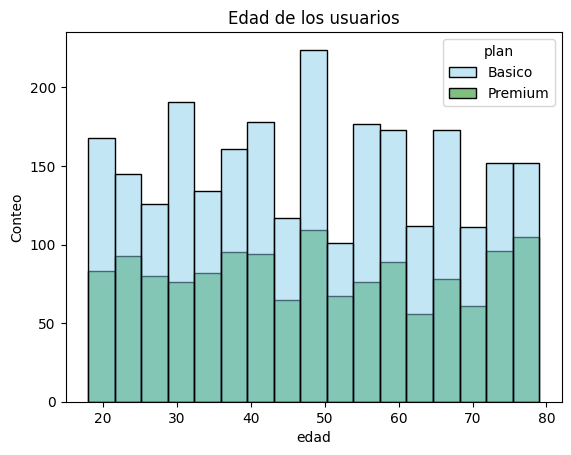

In [74]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Edad de los usuarios')
plt.xlabel('edad')
plt.ylabel('Conteo')
plt.show()


💡Insights: 
- Distribución: la edad tiene una distribución relativamente simétrica entre 20 y 80 años, con un pico alrededor de los 50. No hay como tal un sesgo marcado.
- Relación con el plan: la proporción Básico/Premium se mantiene constante en todos los rangos de edad. No hay un grupo etario que concentre significativamente más usuarios Premium.

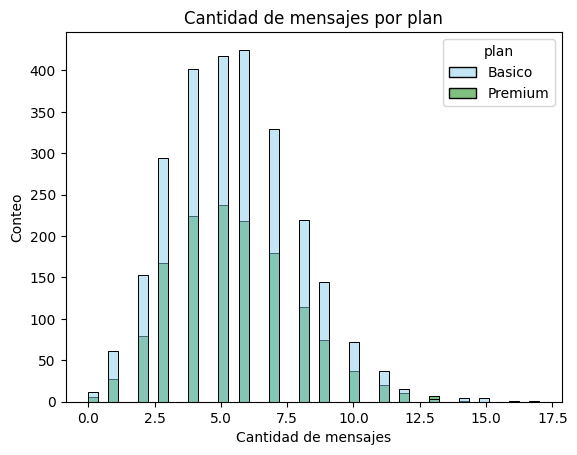

In [75]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Conteo')
plt.show()


💡Insights: 
- Distribución: presenta un leve sesgo a la derecha. La mayoría de usuarios envía entre 3 y 7 mensajes, con pico en 5-6. Los valores extremos superiores a 12 mensajes son pocos.
- Relación con el plan: al igual que con edad, la proporción Básico/Premium es bastante uniforme en todos los niveles de mensajes. Los usuarios Premium no muestran un patrón claro de enviar más o menos mensajes que el plan Básico.

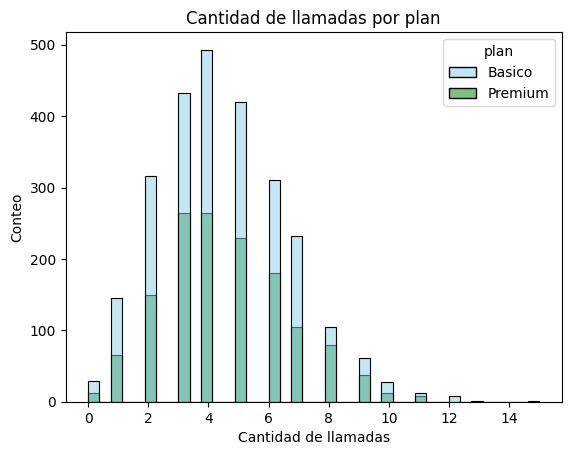

In [76]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Conteo')
plt.show()

💡Insights: 
- Distribución: sesgo leve a la derecha, pico en 4 llamadas. La mayoría de usuarios hace entre 2 y 6 llamadas.
- Relación con el plan: en los rangos bajos (0-2 llamadas) hay más usuarios Básico que Premium. En los rangos medios (3-5) la proporción se equilibra. Posiblemente, usuarios con mayor actividad de voz podrían estar eligiendo plan de voz

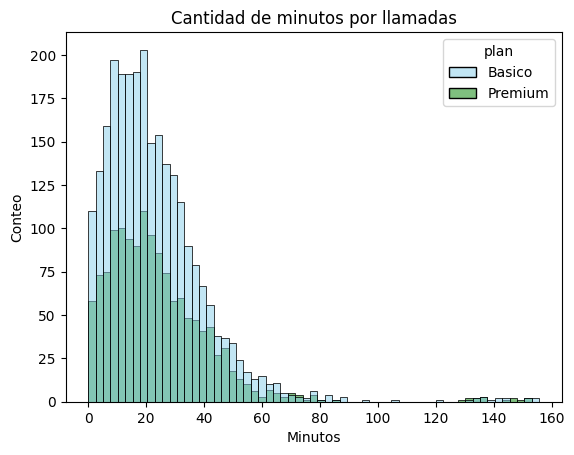

In [77]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de minutos por llamadas')
plt.xlabel('Minutos')
plt.ylabel('Conteo')
plt.show()

💡Insights: 
- Distribución: sesgo a la derecha. El pico principal está alrededor de 20-25 minutos. Usuarios con muy pocas llamadas cortas.
- Posible Outliers: hay usuarios con 130-160 minutos, muy por encima del rango típico. Son pocos pero visibles y son candidatos a revisión como outliers.
- Relación con el plan: similar a las otras variables analizadas ya que la proporción Básico/Premium es uniforme en el rango típico. Sin embargo, en los valores extremos, es decir, superiores a 130+ se ven casi exclusivamente usuarios Premium ya que son usuarios de alto consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

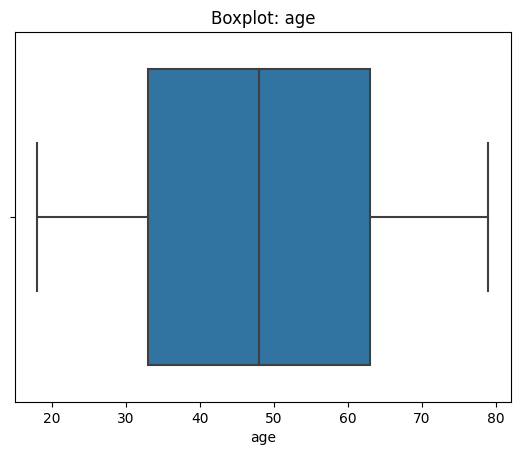

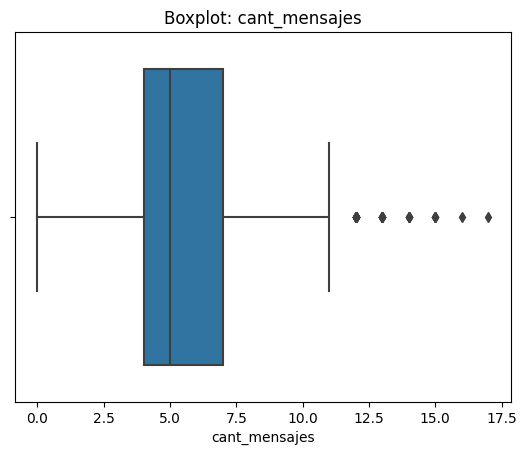

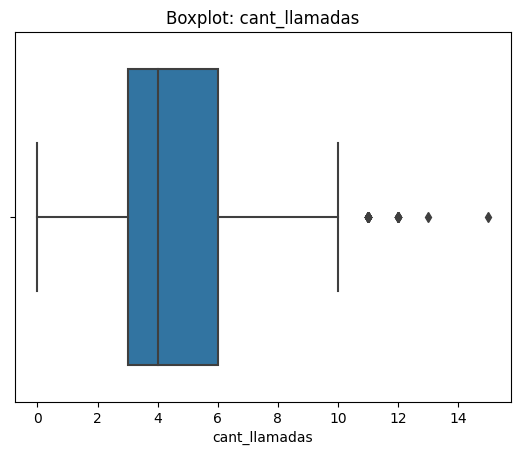

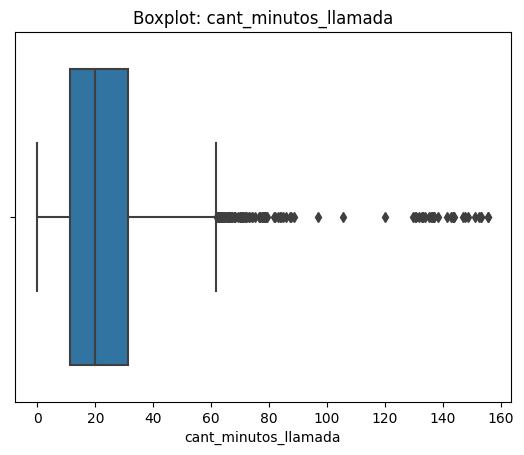

In [78]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: Hay outliers claramente visibles a la derecha en valores superiores a ~11 mensajes. No hay outliers a la izquierda.
- cant_llamadas: Hay outliers claramente visibles a la derecha en valores superiores a ~10 llamadas. No hay outliers a la izquierda.
- cant_minutos_llamada: Hay outliers claramente visibles a la derecha en valores superiores a ~65 minutos. No hay outliers a la izquierda.

In [79]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 +1.5 * IQR
    (f"{col} — límite superior: {limite_superior:.2f}")
    print()
    outliers = (user_profile[col] > limite_superior).sum()
    print(f"{col} — límite superior: {limite_superior:.2f} — outliers: {outliers}") #Calcular el número de datos que son outliers
    


cant_mensajes — límite superior: 11.50 — outliers: 46

cant_llamadas — límite superior: 10.50 — outliers: 30

cant_minutos_llamada — límite superior: 61.86 — outliers: 109


In [80]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

Los outliers presentan un comportamiento real de uso intensivo. En telecomunicaciones un usuario que envía muchos mensajes o habla muchos minutos es posible y son considerados usuarios de alto consumo. Se propone mantener los datos ya que eliminar o capear distorsionaría el perfil de los clientes más activos (clientes más valiosos para ConnectaTel)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:

# Crear columna grupo_uso
def grupo_uso(row):
    llamadas = row["cant_llamadas"]
    mensajes = row["cant_mensajes"]
    
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile["grupo_uso"] = user_profile.apply(grupo_uso, axis=1)


In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [84]:

# Crear columna grupo_edad
def grupo_edad(row):
    edad = row["age"]
        
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile["grupo_edad"] = user_profile.apply(grupo_edad, axis=1)


In [85]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

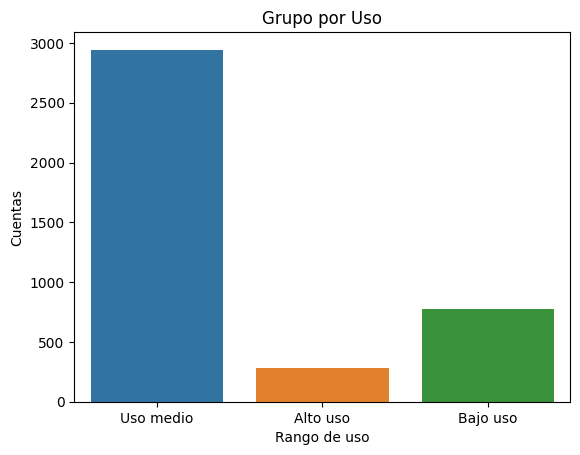

In [87]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")
plt.title('Grupo por Uso')
plt.xlabel('Rango de uso')
plt.ylabel('Cuentas')
plt.show()

In [92]:
print(user_profile["grupo_uso"].value_counts())
print(user_profile["grupo_uso"].value_counts(normalize=True) * 100)
print()
print(pd.crosstab(user_profile["grupo_uso"], user_profile["plan"], normalize="index") * 100)

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64
Uso medio    73.575
Bajo uso     19.450
Alto uso      6.975
Name: grupo_uso, dtype: float64

plan          Basico    Premium
grupo_uso                      
Alto uso   66.666667  33.333333
Bajo uso   65.809769  34.190231
Uso medio  64.458036  35.541964


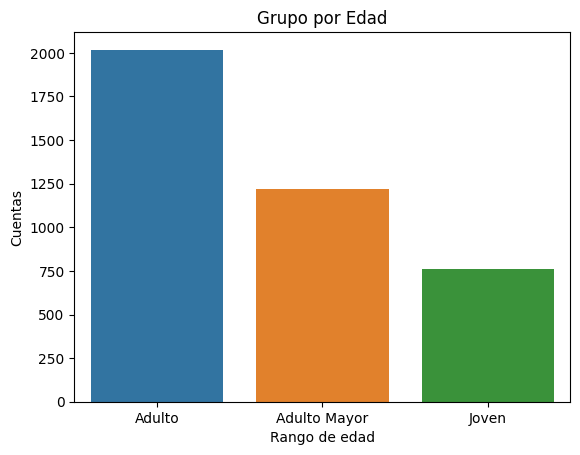

In [89]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.title('Grupo por Edad')
plt.xlabel('Rango de edad')
plt.ylabel('Cuentas')
plt.show()

In [90]:
print(user_profile["grupo_edad"].value_counts())
print(user_profile["grupo_edad"].value_counts(normalize=True) * 100)

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Fechas: reg_date contenía 40 registros con fechas en 2026, imposibles si el corte de datos es 2024. Representan el 1% de la muestra. Acción: marcadas como nulas.
- Sentinel en *age*: valores de -999 en la columna de edad. Distorsionaba la media y desviación estándar de toda la columna. Acción: reemplazados con la mediana.
- Sentinel en *city*: 96 registros con "?" equivalentes al 2.4% de la muestra, más 469 nulos reales (11.7%) para un total: 565 registros sin ciudad válida (14.1%). Acción: unificados como "Unknown" para conservar las filas.
- Nulos en *usage.date*: 50 registros sin fecha (0.125% de 40,000 filas). Acción: drop por impacto mínimo y sin valor lógico para imputar.
- Nulos estructurales en duration y length: confirmados como MAR. Los mensajes no tienen duración y las llamadas no tienen longitud. No requieren acción.


🔍 **Segmentos por Edad**
50.45% Adultos (30-60 años) y corresponde al grupo dominante
30.55% Adultos Mayores (+60 años) correspondiente al segundo grupo relevante
19% Jóvenes (-30 años) grupo minoritario

➡️ Los Adultos Mayores superan a los Jóvenes y sugiere que la oferta debería considerar las necesidades de usuarios maduros, no solo enfocarse en el segmento joven.

📊 **Segmentos por Nivel de Uso**
73.6% Uso medio son gran mayoría
19.5% Bajo uso y son clientes con poca actividad
7% Alto uso. Son la minoría pero potencialmente los más valiosos ya que son los que más consumen los servicios de ConnectaTel. 

➡️ Esto sugiere que los usuarios de Alto uso están en el plan Básico. Eso significa que ConnectaTel tiene clientes que consumen mucho pero pagan poco encontrando una oportunidad clara de migrarlos a Premium.


💡 **Recomendaciones**
- Diseñar una campaña dirigida específicamente al segmento Alto uso + Básico. Son clientes ya comprometidos con el servicio.
- El 30.5% de la base son mayores de 60 años. Este segmento probablemente prioriza llamadas sobre datos, por ende, la creación de un plan con más minutos incluidos y precio accesible orientado a este perfil sería una gran oportunidad de negocio.
- El 14% de registros sin ciudad válida. Validar la ciudad en el proceso de registro para habilitar segmentación regional en futuros análisis.
- Evaluar un plan "Exclusivo" con límites más altos o sin límite. Dicha recomendación se hace a partir de los resultados analizados por los outliers. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`